# 04 — Diebold–Mariano Tests & Thesis Visuals

DM тесты для всех пар моделей + публикационные графики.

**Требуется**: сначала `main.py`

In [6]:
import sys
ROOT = r'D:\clode9'
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)
from thesis_app.notebook_helpers import apply_thesis_plot_style, preferred_xgb_label, best_ml_model_name, significance_stars, interpretation_text
apply_thesis_plot_style()


## Interpretation focus
This notebook tests whether forecast improvements are statistically meaningful. On the defense, connect visual fit with formal DM evidence and avoid claiming superiority without significance support.

In [7]:
import sys, os
ROOT = r'D:\clode9'
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from glob import glob

from thesis_app.pipeline import load_config, build_paths, inv_fisher_z, dm_to_latex

%matplotlib inline
plt.rcParams['figure.dpi'] = 110

cfg = load_config(os.path.join(ROOT, 'config.yaml'))
paths = build_paths(cfg['base_dir'])

csv_files = sorted(glob(os.path.join(paths.predictions, '*_predictions.csv')))
experiments = {
    os.path.basename(f).replace('_predictions.csv', ''): pd.read_csv(f, index_col=0, parse_dates=True)
    for f in csv_files
}
metrics_df = pd.read_csv(os.path.join(paths.results, 'metrics.csv'))
dm_df = pd.read_csv(os.path.join(paths.results, 'dm_tests.csv'))

if 'significant' not in dm_df.columns:
    dm_df['significant'] = dm_df['p_value'].apply(significance_stars)
if 'model_better' not in dm_df.columns:
    dm_df['model_better'] = dm_df['DM_stat'] > 0

print(f'Loaded {len(experiments)} experiments')
print(list(experiments.keys())[:4], '...')
print(f'metrics rows: {len(metrics_df)} | dm rows: {len(dm_df)}')


Loaded 24 experiments
['corr_BTC-USD_ETH-USD_w14_fisher_z', 'corr_BTC-USD_ETH-USD_w30_fisher_z', 'corr_BTC-USD_ETH-USD_w60_fisher_z', 'corr_BTC-USD_ETH-USD_w90_fisher_z'] ...
metrics rows: 192 | dm rows: 48


In [8]:
DM_NW_LAG = int(cfg.get('dm_nw_lag', 0))
preferred_xgb = preferred_xgb_label(metrics_df['model'].unique())
if preferred_xgb is None:
    preferred_xgb = best_ml_model_name(metrics_df)
MODEL_PAIRS = [
    (preferred_xgb, 'DCC_GARCH'),
    (preferred_xgb, 'Naive_Last'),
] if preferred_xgb else []
print('Using ML benchmark:', preferred_xgb)
print(interpretation_text('DM statistic', higher_is_better=True))


Using ML benchmark: XGB_GPU
Interpretation: higher DM statistic indicates stronger practical usefulness in the out-of-sample setting.


In [9]:
ml_label = preferred_xgb_label(dm_df['model'].unique()) or dm_df['model'].mode().iloc[0]
ml_vs_dcc = dm_df[(dm_df['model'] == ml_label) & (dm_df['benchmark'] == 'DCC_GARCH')].copy()

print(f'{ml_label} vs DCC_GARCH:')
if ml_vs_dcc.empty:
    print('No DM rows found for this comparison.')
else:
    print(ml_vs_dcc[['dependency', 'window', 'DM_stat', 'p_value', 'significant', 'model_better']].to_string(index=False))
    print(f'ML better in {int(ml_vs_dcc["model_better"].sum())}/{len(ml_vs_dcc)} tests')
    print('Interpretation: positive DM statistics with low p-values support economically meaningful forecast gains over DCC-GARCH.')


Ridge vs DCC_GARCH:
          dependency  window   DM_stat  p_value significant  model_better
  corr_BTC-USD_^GSPC      14 23.337312      0.0         ***          True
  corr_BTC-USD_^GSPC      30 26.727006      0.0         ***          True
  corr_BTC-USD_^GSPC      60 32.564717      0.0         ***          True
  corr_BTC-USD_^GSPC      90 27.062831      0.0         ***          True
  corr_BTC-USD_^IXIC      14 23.801694      0.0         ***          True
  corr_BTC-USD_^IXIC      30 25.263922      0.0         ***          True
  corr_BTC-USD_^IXIC      60 29.601724      0.0         ***          True
  corr_BTC-USD_^IXIC      90 23.633265      0.0         ***          True
    corr_BTC-USD_GLD      14 20.688998      0.0         ***          True
    corr_BTC-USD_GLD      60 30.266557      0.0         ***          True
    corr_BTC-USD_GLD      90 24.124347      0.0         ***          True
    corr_BTC-USD_SLV      14 24.840745      0.0         ***          True
    corr_BTC-USD_S

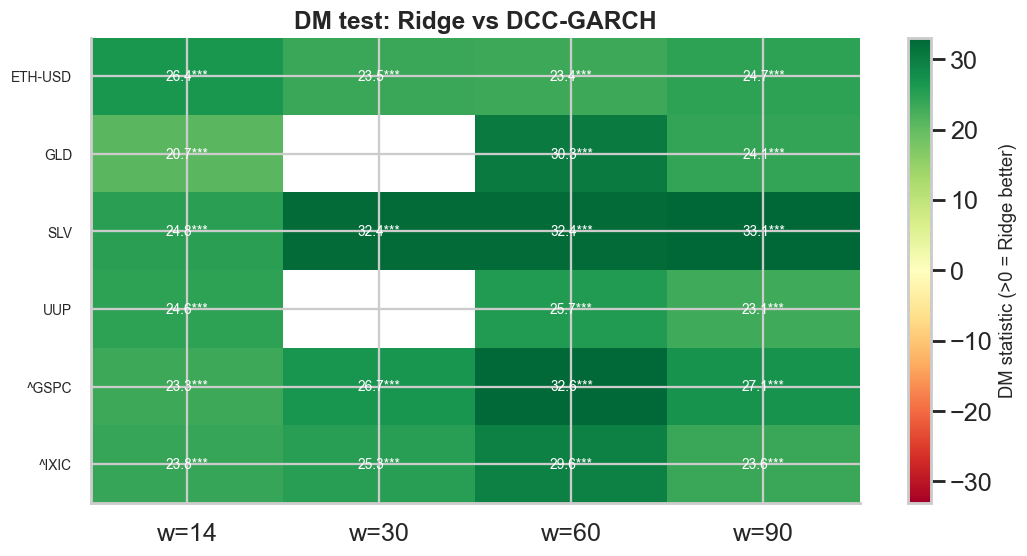

In [10]:
hm = ml_vs_dcc.copy()
hm['pair'] = hm['dependency'].str.replace('corr_BTC-USD_', '', regex=False)

if hm.empty:
    print('Heatmap skipped: no DM results for ML vs DCC.')
else:
    pivot_dm = hm.pivot_table(index='pair', columns='window', values='DM_stat', aggfunc='first')
    vals = pivot_dm.values.astype(float)
    vmax = np.nanmax(np.abs(vals)) if not np.all(np.isnan(vals)) else 5.0

    fig, ax = plt.subplots(figsize=(10, max(4, len(pivot_dm) * 0.9)))
    im = ax.imshow(vals, cmap='RdYlGn', vmin=-vmax, vmax=vmax, aspect='auto')
    ax.set_xticks(range(len(pivot_dm.columns)))
    ax.set_xticklabels([f'w={w}' for w in pivot_dm.columns])
    ax.set_yticks(range(len(pivot_dm.index)))
    ax.set_yticklabels(pivot_dm.index, fontsize=9)

    for i in range(len(pivot_dm.index)):
        for j in range(len(pivot_dm.columns)):
            v = vals[i, j]
            if not np.isnan(v):
                sig = hm[(hm['pair'] == pivot_dm.index[i]) & (hm['window'] == pivot_dm.columns[j])]['significant'].values
                star = sig[0] if len(sig) > 0 else ''
                ax.text(j, i, f'{v:.1f}{star}', ha='center', va='center', fontsize=9,
                        color='white' if abs(v) > vmax * 0.6 else 'black')

    plt.colorbar(im, ax=ax, label=f'DM statistic (>0 = {ml_label} better)')
    ax.set_title(f'DM test: {ml_label} vs DCC-GARCH')
    plt.tight_layout()
    plt.savefig(os.path.join(paths.figures, f'dm_heatmap_{ml_label}_vs_DCC.png'), dpi=140)
    plt.show()


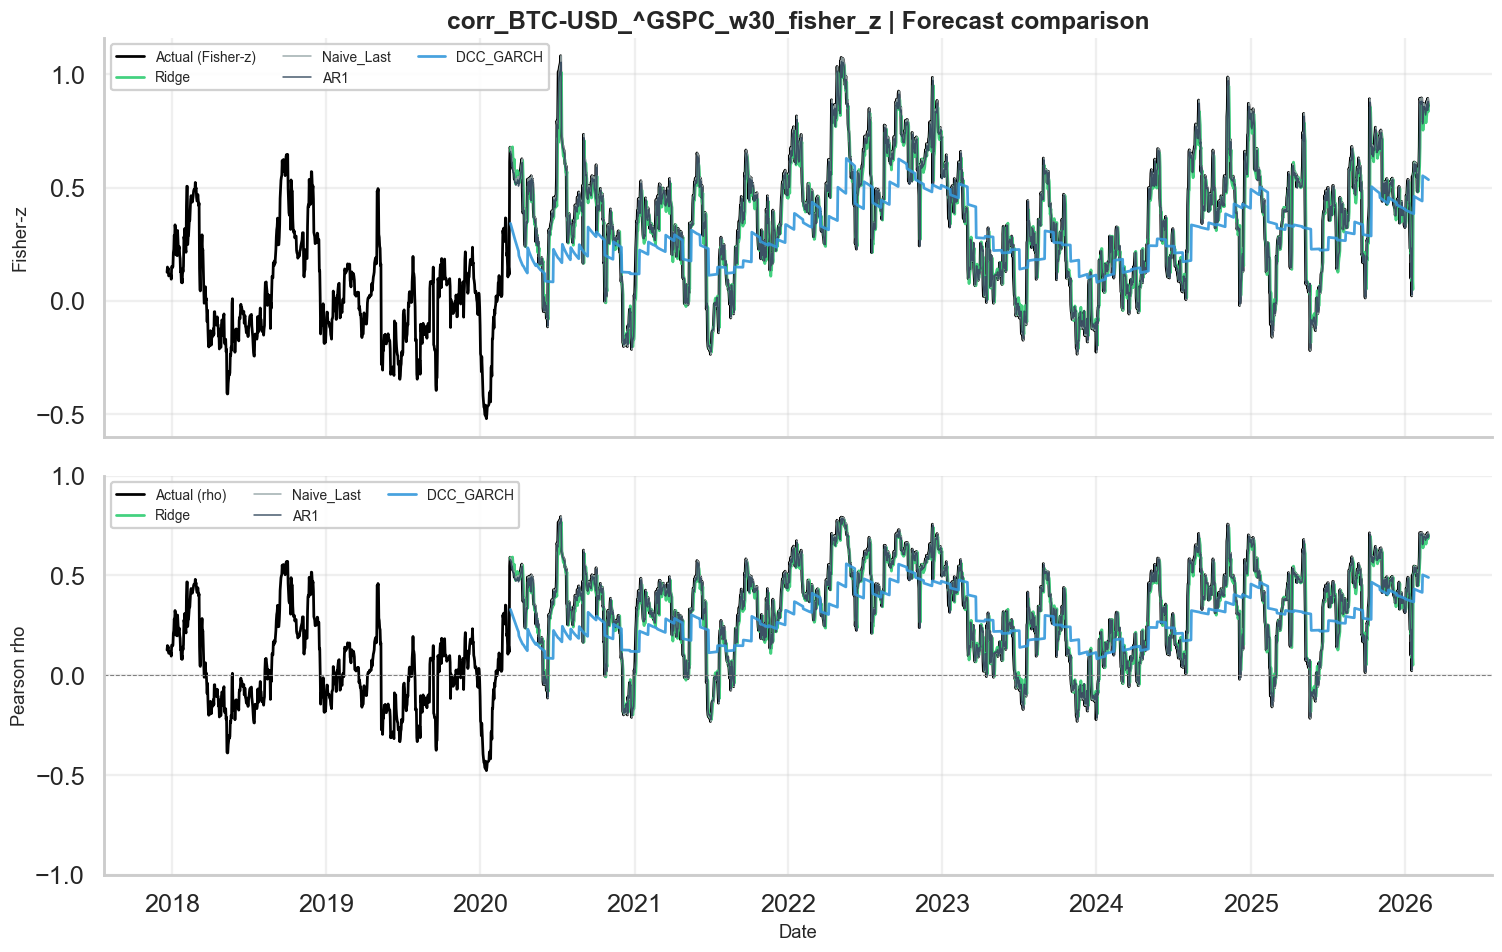

Saved.
Interpretation: compare whether the preferred ML model tracks turning points earlier than DCC and whether both outperform naive persistence only marginally or materially.


In [11]:
SHOWCASE = 'corr_BTC-USD_^GSPC_w30_fisher_z'
if SHOWCASE not in experiments:
    SHOWCASE = list(experiments.keys())[0]
    print(f'Using: {SHOWCASE}')

df = experiments[SHOWCASE]
y_true = df['y_true']
showcase_dependency = SHOWCASE.split('_w')[0]
showcase_window = int(SHOWCASE.split('_w')[1].split('_')[0])
show_metrics = metrics_df[(metrics_df['dependency'] == showcase_dependency) & (metrics_df['window'] == showcase_window)].copy()
preferred_ml = best_ml_model_name(show_metrics) or preferred_xgb_label(df.columns)
plot_models = ['Naive_Last', 'AR1', 'DCC_GARCH']
if preferred_ml:
    plot_models.insert(0, preferred_ml)
plot_models = [m for m in plot_models if m in df.columns and df[m].notna().sum() > 50]

COLORS = {
    'XGB_GPU': '#e74c3c', 'XGB_CPU': '#e74c3c', 'DCC_GARCH': '#3498db',
    'Ridge': '#2ecc71', 'Naive_Last': '#95a5a6', 'RF': '#9b59b6',
    'GBM': '#e67e22', 'AR1': '#34495e', 'ElasticNet': '#16a085'
}

fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=True)

ax = axes[0]
ax.plot(y_true.index, y_true, label='Actual (Fisher-z)', color='black', lw=1.8)
for model in plot_models:
    ax.plot(df.index, df[model], label=model, color=COLORS.get(model, 'gray'),
            lw=1.8 if model in {preferred_ml, 'DCC_GARCH'} else 1.0, alpha=0.9)
ax.set_ylabel('Fisher-z')
ax.set_title(f'{SHOWCASE} | Forecast comparison')
ax.legend(ncol=3, fontsize=9)
ax.grid(alpha=0.3)

ax2 = axes[1]
ax2.plot(y_true.index, inv_fisher_z(y_true), label='Actual (rho)', color='black', lw=1.8)
for model in plot_models:
    ax2.plot(df.index, inv_fisher_z(df[model]), label=model, color=COLORS.get(model, 'gray'),
             lw=1.8 if model in {preferred_ml, 'DCC_GARCH'} else 1.0, alpha=0.9)
ax2.axhline(0, color='gray', lw=0.7, ls='--')
ax2.set_ylabel('Pearson rho')
ax2.set_xlabel('Date')
ax2.legend(ncol=3, fontsize=9)
ax2.grid(alpha=0.3)
ax2.set_ylim(-1, 1)

plt.tight_layout()
plt.savefig(os.path.join(paths.figures, f'thesis_forecast_{SHOWCASE}.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Saved.')
print('Interpretation: compare whether the preferred ML model tracks turning points earlier than DCC and whether both outperform naive persistence only marginally or materially.')


In [12]:
summary = dm_df.groupby(['model', 'benchmark']).agg(
    n_tests=('DM_stat', 'count'),
    n_sig=('significant', lambda x: (x != '').sum()),
    n_better=('model_better', 'sum'),
    mean_DM=('DM_stat', 'mean'),
).round(3)
print('DM summary:')
print(summary.to_string())

tex_path = os.path.join(paths.tables, 'dm_tests_full.tex')
dm_to_latex(dm_df, tex_path)
print(f'LaTeX saved: {tex_path}')
print('DM tests complete.')


DM summary:
                       n_tests  n_sig  n_better  mean_DM
model      benchmark                                    
ElasticNet DCC_GARCH         2      2         2   26.057
           Naive_Last        2      2         0  -10.925
Ridge      DCC_GARCH        22     22        22   26.414
           Naive_Last       22     22         0  -10.119
LaTeX saved: D:/clode9\outputs\tables\dm_tests_full.tex
DM tests complete.
